<a href="https://colab.research.google.com/github/TomazDrumond/TomazDrumond.github.io/blob/main/MacroReport.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Base de dados para o **Macro report 1 st season**

## Importando as bibliotecas necessárias

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  IMPORTAÇÃO DE BIBLIOTECAS — usadas em todas as seções do relatório
# ══════════════════════════════════════════════════════════════════════════════

# Instalação dos pacotes não nativos do ambiente
!pip install python-bcb pandas-datareader openpyxl statsmodels arch matplotlib -q

# --- Utilitários gerais ---
import os                          # checagem de caminhos de arquivo (ex.: fontes)
import json                        # leitura de respostas JSON (APIs)
import time                        # pausas entre requisições (rate limit)
import itertools                   # combinações (grids de parâmetros)
import warnings                    # controle de avisos exibidos no notebook
import requests                    # requisições HTTP (ex.: API Polymarket)
from datetime import date          # datas de referência

# --- Manipulação de dados ---
import pandas as pd                # DataFrames e séries temporais
import numpy as np                 # álgebra linear e operações numéricas

# --- Visualização ---
import matplotlib.pyplot as plt    # gráficos
import matplotlib.dates as mdates  # formatação de eixos temporais
import matplotlib.font_manager as fm   # registro de fontes customizadas
import seaborn as sns              # gráficos estatísticos complementares
from matplotlib.patches import FancyBboxPatch

# --- Coleta de dados macroeconômicos ---
from bcb import sgs                        # séries do SGS/Banco Central
import pandas_datareader.data as pdr       # séries de fontes externas (ex.: FRED)
import yfinance as yf

# --- Econometria: testes e modelos ---
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss, coint, grangercausalitytests, acf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.api import VAR
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
from statsmodels.tsa.statespace.sarimax import SARIMAX
from arch import arch_model                # modelos GARCH

# --- Otimização e estatística ---
from scipy.optimize import brentq
import scipy.stats as stats
sp_stats = stats                   # alias usado em algumas seções do notebook

warnings.filterwarnings("ignore")

# --- Estilo padrão dos gráficos (paleta institucional) ---
plt.rcParams.update({
    "font.size": 10.5,
    "figure.figsize": (8, 5),
    "axes.titlesize": 20,
    "axes.titleweight": "bold",
    "axes.titlepad": 18,
    "axes.labelsize": 12,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 12,
    "legend.title_fontsize": 12,
    "lines.linewidth": 2.8,
    "lines.markersize": 4,
    "axes.grid": True,
    "grid.alpha": 0.3,
})
cores = [
    "#0B1F3A", "#AFCBE3", "#4F7FAE", "#9E2B2B", "#8A6F3D",
    "#2E4A3F", "#C46013", "#EDC948", "#C2B280", "#C51700",
    "#6F4E9B", "#008C8C", "#B23A48", "#5B8FF9", "#2F5D62",
]
proporcao = [0, 0, 0.8, 0.8]

print("✔  Ambiente configurado — bibliotecas, paleta e estilo prontos para todo o relatório.")


## Impacto do desenrola brasil 2.0

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  CÉLULA 1 — Coleta otimizada
# ══════════════════════════════════════════════════════════════════════════════

DATA_INICIO = "2018-01-01"
DATA_FIM    = date.today().strftime("%Y-%m-%d")

SERIES = {
    "inadimplencia_pf_cartao"    : 21129,   # dependente [%]
    "comprometimento_renda_total": 29034,   # único canal causal validado [%]
    "massa_salarial_real"        : 28544,   # controle de renda real [R$ Mn]
    "pib_ibc_br"                 : 24363,   # proxy mensal de PIB [x100]
    "selic"                      : 4390,    # taxa efetiva [%]
    "ipca"                       : 7478     # controle de inflação [%]
}

COR_FUNDO = "#0D1117"
COR_TEXTO = "#C9D1D9"
COR_GRADE = "#1E2D3D"
CORES = {
    "inadimplencia_pf_cartao"          : "#E63946",
    "comprometimento_renda_total"      : "#457B9D",
    "massa_salarial_real"              : "#F4A261",
    "pib_ibc_br"                       : "#2A9D8F",
    "selic"                            : "#264653",
    "ipca"                             : "#E9C46A"
}

# Criamos um vetor com as séries que hão de ser importadas

LABELS = {
    "inadimplencia_pf_cartao"     : "PF – cartão de crédito",
    "comprometimento_renda_total" : "Comprometimento renda",
    "ipca"                        : "IPCA-15",
    "massa_salarial_real"         : "Massa salarial real",
    "pib_ibc_br"                  : "IBC-Br",
    "selic"                       : "Selic"
}

MARCOS = {
    "Desenrola 1.0 — Lançamento" : "2023-11-01",
    "Desenrola 1.0 — Fim adesão" : "2024-05-31",
    "Desenrola 2.0 — Lançamento" : "2026-05-04",
}
ESTILO_MARCOS = {
    "Desenrola 1.0 — Lançamento" : ("#2196F3", "--", "D1.0"),
    "Desenrola 1.0 — Fim adesão" : ("#90CAF9", ":",  "D1.0 fim"),
    "Desenrola 2.0 — Lançamento" : ("#FF9800", "--", "D2.0"),
}

def baixar_serie(nome, codigo, inicio, fim):
    print(f"  ↓  {nome:28s} (SGS {codigo}) ...", end=" ")
    try:
        df_s = sgs.get({nome: codigo}, start=inicio, end=fim)
        df_s.index = pd.to_datetime(df_s.index)
        print(f"OK — {len(df_s)} obs.")
        return df_s[nome]
    except Exception as e:
        print(f"ERRO: {e}")
        return pd.Series(dtype=float, name=nome)

print("🔽 Baixando séries otimizadas...\n")
resultados = {}
for nome, codigo in SERIES.items():
    serie = baixar_serie(nome, codigo, DATA_INICIO, DATA_FIM)
    if not serie.empty:
        resultados[nome] = serie

df = pd.concat(resultados.values(), axis=1)
df.columns = resultados.keys()
df.sort_index(inplace=True)
print(f"\n✔  {len(resultados)}/{len(SERIES)} séries obtidas | Shape: {df.shape}")

def adicionar_marcos(ax, df_ref):
    for label, (cor, estilo, sigla) in ESTILO_MARCOS.items():
        data = pd.Timestamp(MARCOS[label])
        if df_ref.index.min() <= data <= df_ref.index.max():
            ax.axvline(data, color=cor, linestyle=estilo,
                       linewidth=1.2, alpha=0.85, zorder=3)
            ylim = ax.get_ylim()
            ax.text(data, ylim[1] * 0.97, f" {sigla}",
                    color=cor, fontsize=7, va="top", rotation=90)

🔽 Baixando séries otimizadas...

  ↓  inadimplencia_pf_cartao      (SGS 21129) ... OK — 102 obs.
  ↓  comprometimento_renda_total  (SGS 29034) ... OK — 101 obs.
  ↓  massa_salarial_real          (SGS 28544) ... OK — 101 obs.
  ↓  pib_ibc_br                   (SGS 24363) ... OK — 101 obs.
  ↓  selic                        (SGS 4390) ... OK — 104 obs.
  ↓  ipca                         (SGS 7478) ... OK — 103 obs.

✔  6/6 séries obtidas | Shape: (104, 6)


In [ ]:
# Fazemos o cálculo de variação % do IBC-Br, a fim de manter o padrão interpretativo

df["pib_ibc_br_sa"] = df["pib_ibc_br"].pct_change() * 100

# Estatisticas descritivas

df.describe()

,inadimplencia_pf_cartao,comprometimento_renda_total,massa_salarial_real,pib_ibc_br,selic,ipca,pib_ibc_br_sa
count,102.000000,101.000000,101.000000,101.000000,104.000000,103.000000,103.000000
mean,6.851765,24.950693,327049.039604,100.664522,0.722308,0.432621,0.257253
std,1.514227,2.403105,38244.040050,6.580614,0.343362,0.387974,4.000659
min,3.790000,19.770000,260361.000000,83.958150,0.130000,-0.730000,-12.034549
25%,5.807500,22.650000,298488.000000,96.506060,0.470000,0.185000,-2.357896
50%,6.935000,25.600000,318757.000000,99.797770,0.790000,0.390000,-0.128750
75%,7.922500,26.960000,353323.000000,105.475220,1.022500,0.665000,2.476004
max,9.590000,28.480000,422982.000000,117.808900,1.280000,1.730000,12.023101


In [ ]:
# Testa se cada série tem componente sazonal estatisticamente significativo
# antes de decidir se vale dessazonalizar

def teste_sazonalidade(serie, nome, periodo=12):
    s = serie.dropna()
    if len(s) < 24:
        print(f"  {nome:<42s} ⚠️  série curta — ignorado")
        return False

    # ACF no lag sazonal
    acf_vals, confint = acf(s, nlags=periodo, alpha=0.05)
    acf_lag  = acf_vals[periodo]
    ci_low   = confint[periodo][0] - acf_lag
    ci_high  = confint[periodo][1] - acf_lag
    acf_sig  = not (ci_low <= 0 <= ci_high)

    # F-test dummies mensais
    df_aux = pd.DataFrame({"y": s})
    df_aux.index = pd.to_datetime(df_aux.index)
    for m in range(2, 13):
        df_aux[f"m{m:02d}"] = (df_aux.index.month == m).astype(int)
    X       = sm.add_constant(df_aux[[f"m{m:02d}" for m in range(2, 13)]])
    mod_c   = sm.OLS(df_aux["y"], X).fit()
    mod_r   = sm.OLS(df_aux["y"], sm.add_constant(
                pd.Series(np.ones(len(df_aux)), index=df_aux.index))).fit()
    F       = ((mod_r.ssr - mod_c.ssr) / 11) / (mod_c.ssr / mod_c.df_resid)
    p_f     = 1 - stats.f.cdf(F, 11, mod_c.df_resid)
    ftest_sig = p_f < 0.05

    tem_saz = acf_sig or ftest_sig
    status  = "✅ Sazonal" if tem_saz else "✗  Sem sazonalidade"
    print(f"  {nome:<42s} ACF(12)={acf_lag:+.3f} {'sig' if acf_sig else 'n.s.':>4}"
          f" | F p={p_f:.3f} {'sig' if ftest_sig else 'n.s.':>4} | {status}")
    return tem_saz

print("=" * 75)
print("  DIAGNÓSTICO DE SAZONALIDADE — ACF(12) + F-test dummies mensais")
print("=" * 75)

resultados_saz = {}
for col in df.columns:
    resultados_saz[col] = teste_sazonalidade(df[col], col)

SERIES_COM_SAZ = [k for k, v in resultados_saz.items() if v]
SERIES_SEM_SAZ = [k for k, v in resultados_saz.items() if not v]

print(f"\n  Séries COM sazonalidade ({len(SERIES_COM_SAZ)}): {SERIES_COM_SAZ}")
print(f"  Séries SEM sazonalidade ({len(SERIES_SEM_SAZ)})")
print(f"\n✔  Apenas {len(SERIES_COM_SAZ)} série(s) serão dessazonalizadas.")

  DIAGNÓSTICO DE SAZONALIDADE — ACF(12) + F-test dummies mensais
  inadimplencia_pf_cartao                    ACF(12)=+0.248 n.s. | F p=0.999 n.s. | ✗  Sem sazonalidade
  comprometimento_renda_total                ACF(12)=+0.465 n.s. | F p=1.000 n.s. | ✗  Sem sazonalidade
  massa_salarial_real                        ACF(12)=+0.646 n.s. | F p=0.096 n.s. | ✗  Sem sazonalidade
  pib_ibc_br                                 ACF(12)=+0.648 n.s. | F p=0.086 n.s. | ✗  Sem sazonalidade
  selic                                      ACF(12)=+0.507 n.s. | F p=1.000 n.s. | ✗  Sem sazonalidade
  ipca                                       ACF(12)=+0.089 n.s. | F p=0.185 n.s. | ✗  Sem sazonalidade
  pib_ibc_br_sa                              ACF(12)=+0.659 n.s. | F p=0.000  sig | ✅ Sazonal

  Séries COM sazonalidade (1): ['pib_ibc_br_sa']
  Séries SEM sazonalidade (6)

✔  Apenas 1 série(s) serão dessazonalizadas.


In [ ]:
# Roda sobre df_dessaz: inclui massa_salarial_real_sa (dessazonalizada)
# e exclui a original massa_salarial_real (substituída pela versão _sa)

df_dessaz = df.copy()
ordens = {}

def teste_adf(serie, max_diff=2):
    s = serie.dropna()
    for d in range(max_diff + 1):
        stat, p, *_ = adfuller(s, autolag="AIC")
        if p < 0.05:
            return d, p
        s = s.diff().dropna()
    return max_diff, p

def teste_kpss_p(serie):
    s = serie.dropna()
    _, p, *_ = kpss(s, regression="c", nlags="auto")
    return p

def classificar_serie(col, d, adf_p, kpss_p):
    if d == 0 and kpss_p > 0.05:
        status = "✅ I(0) — estacionária"
    elif d == 1:
        status = "⚠️  I(1) — 1ª diferença"
    elif d == 2:
        status = "🔴 I(2) — 2ª diferença"
    else:
        status = "❓ Inconclusivo"
    print(f"  {col:<42s} I({d}) | ADF p={adf_p:.4f} | KPSS p={kpss_p:.4f} | {status}")
    return d

# Colunas a testar: todas do df_dessaz exceto a original que foi substituída

PULAR_ADF   = ["D1_", "D2_", "mes_", "selic_lag"]

print("=" * 75)
print("  DIAGNÓSTICO DE ESTACIONARIEDADE — ADF + KPSS")
print("=" * 75)

ordens = {}
for col in df_dessaz.columns:
    if any(col.startswith(p) for p in PULAR_ADF):
        continue
    serie = df_dessaz[col].dropna()
    if len(serie) < 20:
        continue
    d, adf_p    = teste_adf(serie)
    kpss_p      = teste_kpss_p(serie)
    ordens[col] = classificar_serie(col, d, adf_p, kpss_p)

series_I0 = [k for k, v in ordens.items() if v == 0]
series_I1 = [k for k, v in ordens.items() if v == 1]
series_I2 = [k for k, v in ordens.items() if v == 2]

print(f"\n{'─'*75}")
print(f"  I(0): {series_I0}")
print(f"  I(1): {series_I1}")
print(f"  I(2): {series_I2}")
print(f"\n✔  ordens criado — {len(ordens)} séries classificadas")

  DIAGNÓSTICO DE ESTACIONARIEDADE — ADF + KPSS
  inadimplencia_pf_cartao                    I(1) | ADF p=0.0004 | KPSS p=0.0100 | ⚠️  I(1) — 1ª diferença
  comprometimento_renda_total                I(1) | ADF p=0.0000 | KPSS p=0.0100 | ⚠️  I(1) — 1ª diferença
  massa_salarial_real                        I(2) | ADF p=0.0005 | KPSS p=0.0100 | 🔴 I(2) — 2ª diferença
  pib_ibc_br                                 I(1) | ADF p=0.0070 | KPSS p=0.0100 | ⚠️  I(1) — 1ª diferença
  selic                                      I(2) | ADF p=0.1246 | KPSS p=0.0100 | 🔴 I(2) — 2ª diferença
  ipca                                       I(0) | ADF p=0.0000 | KPSS p=0.1000 | ✅ I(0) — estacionária
  pib_ibc_br_sa                              I(0) | ADF p=0.0060 | KPSS p=0.1000 | ✅ I(0) — estacionária

───────────────────────────────────────────────────────────────────────────
  I(0): ['ipca', 'pib_ibc_br_sa']
  I(1): ['inadimplencia_pf_cartao', 'comprometimento_renda_total', 'pib_ibc_br']
  I(2): ['massa_sala

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  CÉLULA 3 — Seleção via Granger com lag adaptativo
# ══════════════════════════════════════════════════════════════════════════════

DEPENDENTE    = "inadimplencia_pf_cartao"
ALPHA_GRANGER = 0.10

series_I1 = [c for c in series_I1 if c not in ("concessao_credito"," massa_salarial_real")]
series_I0 = [c for c in series_I0 if c not in ("concessao_credito"," massa_salarial_real")]
CANDIDATAS = [c for c in (series_I0 + series_I1) if c != DEPENDENTE and c in df_dessaz.columns]

_df_I1_diff = df_dessaz[[c for c in CANDIDATAS if c in series_I1] + [DEPENDENTE]].diff().dropna()
_df_I0_nivel = df_dessaz[[c for c in CANDIDATAS if c in series_I0]]

_df_pre = pd.concat([_df_I1_diff, _df_I0_nivel], axis=1).dropna()

LAG_SELECAO = max(VAR(_df_pre).select_order(maxlags=12).bic, 1)

print(f"  Lag adaptativo: {LAG_SELECAO}\n  Candidatas: {CANDIDATAS}\n")

SELECIONADAS = []
for cand in CANDIDATAS:
    dados_g = df_dessaz[[DEPENDENTE, cand]].diff().dropna()
    res_g   = grangercausalitytests(dados_g, maxlag=LAG_SELECAO, verbose=False)
    p_min   = min(res_g[l][0]["ssr_ftest"][1] for l in range(1, LAG_SELECAO+1))
    sig     = "✅" if p_min < ALPHA_GRANGER else "✗"
    print(f"  {cand:<28s} p={p_min:.4f}  {sig}")
    if p_min < ALPHA_GRANGER:
        SELECIONADAS.append(cand)

ENDOGENAS_FINAL = [DEPENDENTE] + SELECIONADAS
EXOGENA_FINAL = "selic" if ("selic" in series_I0 + series_I1) and ("selic" not in ENDOGENAS_FINAL) else None
print(f"\n✔  Endógenas: {ENDOGENAS_FINAL}\n✔  Exógena: {EXOGENA_FINAL}")

  Lag adaptativo: 1
  Candidatas: ['ipca', 'pib_ibc_br_sa', 'comprometimento_renda_total', 'pib_ibc_br']

  ipca                         p=0.0104  ✅
  pib_ibc_br_sa                p=0.6491  ✗
  comprometimento_renda_total  p=0.0075  ✅
  pib_ibc_br                   p=0.1892  ✗

✔  Endógenas: ['inadimplencia_pf_cartao', 'ipca', 'comprometimento_renda_total']
✔  Exógena: None


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  CÉLULA 4 — BVAR(1) Minnesota Prior
# ══════════════════════════════════════════════════════════════════════════════

ENDOGENAS_DESENROLA = ['inadimplencia_pf_cartao','comprometimento_renda_total','pib_ibc_br_sa','ipca', 'selic']
LAMBDA1_DESENROLA = 1.0
LAG_DESENROLA = 1

Y_matrix_desenrola = df_dessaz[ENDOGENAS_DESENROLA].diff().dropna().values

def montar_matriz_lags(Y, p):
    T, K = Y.shape
    Yt = Y[p:]
    Ylag = np.column_stack([Y[p-l:T-l] for l in range(1, p+1)])
    Ylag = np.column_stack([np.ones(T-p), Ylag])
    return Ylag, Yt

def bvar_minnesota(Y, p, lambda1=1.0, lambda2=0.5):
    T, K = Y.shape
    Ylag, Yt = montar_matriz_lags(Y, p)
    n_coef = 1 + K*p
    b_prior = np.zeros((n_coef, K))
    for i in range(K):
        b_prior[1+i, i] = 1.0
    V_diag = np.full(n_coef, lambda1**2)
    for l in range(p):
        for i in range(K):
            V_diag[1+l*K+i] = (lambda1/((l+1)**lambda2))**2
    V_prior_inv = np.diag(1/V_diag)
    XtX, XtY = Ylag.T @ Ylag, Ylag.T @ Yt
    V_post = np.linalg.inv(V_prior_inv + XtX)
    B_post = V_post @ (V_prior_inv @ b_prior + XtY)
    resid = Yt - Ylag @ B_post
    Sigma_post = (resid.T @ resid) / (T - p)
    return B_post, Sigma_post, V_post, Ylag, Yt

B_post_des, Sigma_post_des, V_post_des, Ylag_des, Yt_des = bvar_minnesota(
    Y_matrix_desenrola, LAG_DESENROLA, LAMBDA1_DESENROLA
)

resid_des = Yt_des - Ylag_des @ B_post_des
lb_des = acorr_ljungbox(resid_des[:, 0], lags=[6, 12], return_df=True)

print(f"✔  BVAR({LAG_DESENROLA}) Desenrola 2.0 | λ1={LAMBDA1_DESENROLA} | "
      f"K={len(ENDOGENAS_DESENROLA)} variáveis | "
      f"Ljung-Box p_min={lb_des['lb_pvalue'].min():.4f}")
print(f"   Endógenas: {ENDOGENAS_DESENROLA}")

✔  BVAR(1) Desenrola 2.0 | λ1=1.0 | K=5 variáveis | Ljung-Box p_min=0.4348
   Endógenas: ['inadimplencia_pf_cartao', 'comprometimento_renda_total', 'pib_ibc_br_sa', 'ipca', 'selic']


  Ljung-Box (resíduo BVAR, variável dependente):
      lb_stat  lb_pvalue
6    4.581875   0.598443
12  12.135985   0.434821

  Correlação contemporânea dos resíduos:
                               D_inadimplencia_pf_cartao  D_comprometimento_renda_total  D_pib_ibc_br_sa  D_ipca  D_selic
D_inadimplencia_pf_cartao                          1.000                         -0.067           -0.222  -0.023   -0.233
D_comprometimento_renda_total                     -0.067                          1.000           -0.119   0.047    0.049
D_pib_ibc_br_sa                                   -0.222                         -0.119            1.000   0.174    0.245
D_ipca                                            -0.023                          0.047            0.174   1.000   -0.124
D_selic                                           -0.233                          0.049            0.245  -0.124    1.000


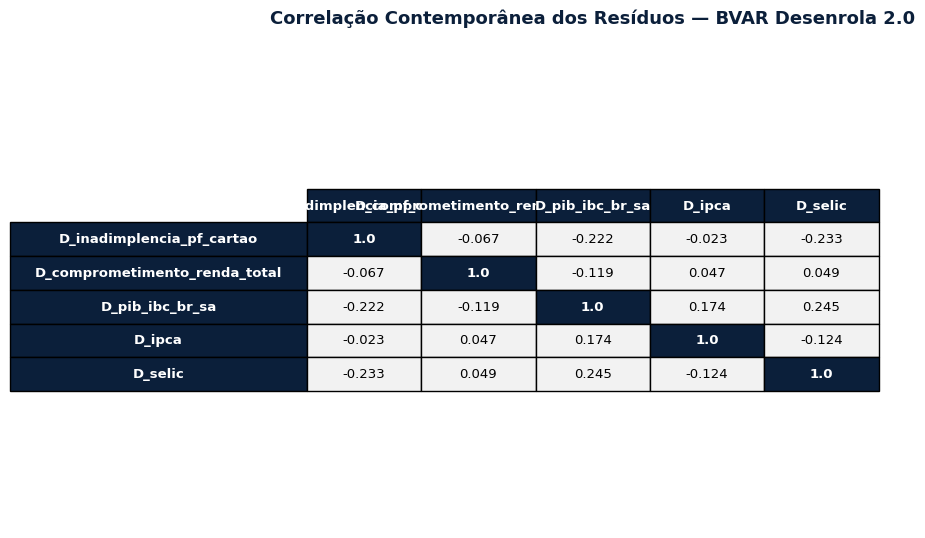

✔  Destaque em vermelho: |correlação| > 0,3 (atenção à ordenação de Cholesky nesses pares)


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  CÉLULA 4— Tabela formatada da matriz de correlação contemporânea
# ══════════════════════════════════════════════════════════════════════════════

resid_bvar = Yt_des - Ylag_des @ B_post_des
resid_df = pd.DataFrame(resid_bvar, columns=[f"D_{c}" for c in ENDOGENAS_DESENROLA])

lb_result = acorr_ljungbox(resid_df.iloc[:, 0], lags=[6, 12], return_df=True)
print("  Ljung-Box (resíduo BVAR, variável dependente):")
print(lb_result.to_string())

print(f"\n  Correlação contemporânea dos resíduos:")
print(resid_df.corr().round(3).to_string())

corr_matrix = resid_df.corr().round(3)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.axis("off")

tabela = ax.table(
    cellText=corr_matrix.values,
    rowLabels=corr_matrix.index,
    colLabels=corr_matrix.columns,
    cellLoc="center",
    rowLoc="center",
    loc="center",
)
tabela.auto_set_font_size(False)
tabela.set_fontsize(9.5)
tabela.scale(1, 1.8)

# Destaca a diagonal (sempre 1.0) e células com |correlação| > 0.3 (moderada/alta)
n = len(corr_matrix)
for i in range(n):
    for j in range(n):
        cell = tabela[(i + 1, j)]
        valor = corr_matrix.values[i, j]
        if i == j:
            cell.set_facecolor(cores[0])
            cell.set_text_props(color="white", fontweight="bold")
        elif abs(valor) > 0.3:
            cell.set_facecolor(cores[9])
            cell.set_text_props(color="white", fontweight="bold")
        else:
            cell.set_facecolor("#F2F2F2")

for j in range(n):
    tabela[(0, j)].set_facecolor(cores[0])
    tabela[(0, j)].set_text_props(color="white", fontweight="bold")
for i in range(n):
    tabela[(i + 1, -1)].set_facecolor(cores[0])
    tabela[(i + 1, -1)].set_text_props(color="white", fontweight="bold")

ax.set_title("Correlação Contemporânea dos Resíduos — BVAR Desenrola 2.0",
             fontsize=13, fontweight="bold", color=cores[0], pad=20)

plt.tight_layout()
plt.savefig("matriz_correlacao_residuos_bvar.png", dpi=300, bbox_inches="tight")
plt.show()

print("✔  Destaque em vermelho: |correlação| > 0,3 (atenção à ordenação de Cholesky nesses pares)")



In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  CÉLULA 5.9 — Sensibilidade a lags maiores (reestima BVAR com p=2,3,4)
#  Reaproveita bvar_minnesota() já definida na Célula 4
# ══════════════════════════════════════════════════════════════════════════════

resultados_lag = {}

for p_teste in [6,12,24,36,48]:
    B_post_p, Sigma_post_p, V_post_p, Ylag_p, Yt_p = bvar_minnesota(
        Y_matrix_desenrola, p_teste, LAMBDA1_DESENROLA
    )
    resid_p = Yt_p - Ylag_p @ B_post_p
    lb_p = acorr_ljungbox(resid_p[:, 0], lags=[6, 12], return_df=True)

    resultados_lag[p_teste] = {
        "B_post": B_post_p, "Sigma_post": Sigma_post_p, "V_post": V_post_p,
        "lb_pmin": lb_p["lb_pvalue"].min(),
        "n_obs": len(Yt_p),
    }
    print(f"  lag={p_teste} | n_obs={len(Yt_p):3d} | Ljung-Box p_min={lb_p['lb_pvalue'].min():.4f}")

print(f"\n✔  Lag atual do modelo principal: {LAG_DESENROLA}")
print("   Comparar Ljung-Box entre lags — se p_min piorar muito em p=1 vs. outros, considerar aumentar")

  lag=6 | n_obs= 93 | Ljung-Box p_min=0.1656
  lag=12 | n_obs= 87 | Ljung-Box p_min=0.0046
  lag=24 | n_obs= 75 | Ljung-Box p_min=0.1689
  lag=36 | n_obs= 63 | Ljung-Box p_min=0.1140
  lag=48 | n_obs= 51 | Ljung-Box p_min=0.0003

✔  Lag atual do modelo principal: 1
   Comparar Ljung-Box entre lags — se p_min piorar muito em p=1 vs. outros, considerar aumentar


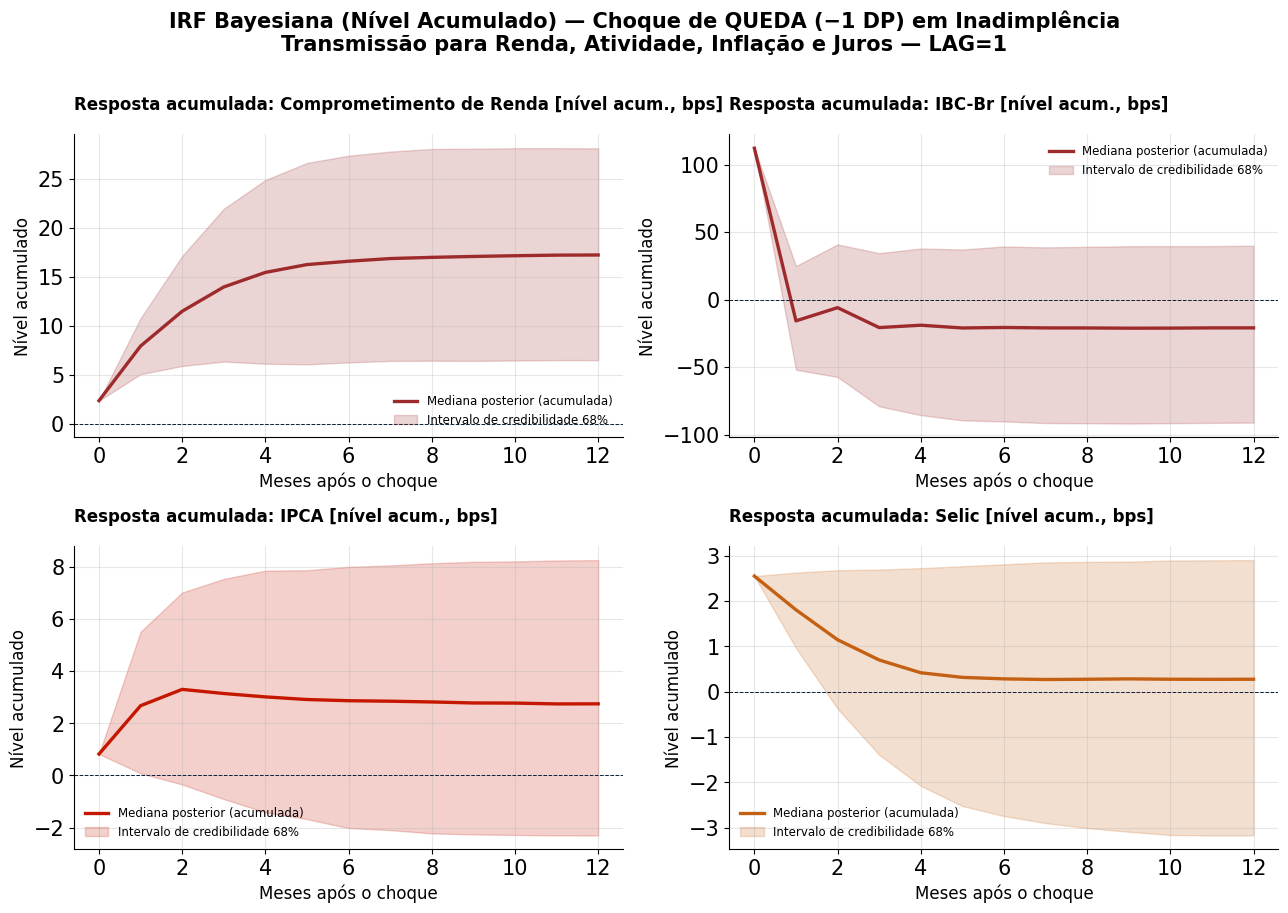

✔  IRF em nível acumulado (IC 68%) — 5 variáveis, 1000 draws, LAG=1


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#   CÉLULA 6 — IRF Bayesiana (Intervalo de Credibilidade de 68%)
# ══════════════════════════════════════════════════════════════════════════════

N_DRAWS = 1000
HORIZONTE_IRF = 12
K = len(ENDOGENAS_DESENROLA)


def simular_irf_bayesiana(
    B_post, V_post, Sigma_post, K, p, n_draws, horizonte, sinal_choque=None
):
    irfs = np.zeros((n_draws, horizonte + 1, K, K))
    for draw in range(n_draws):
        B_draw = B_post.copy()
        for j in range(K):
            cov_col = V_post * Sigma_post[j, j]
            B_draw[:, j] = np.random.multivariate_normal(
                B_post[:, j], cov_col
            )

        chol = np.linalg.cholesky(Sigma_post)
        if sinal_choque is not None:
            chol = (
                chol * sinal_choque[np.newaxis, :]
            )  # inverte sinal da(s) coluna(s) desejada(s)

        irf_atual = np.zeros((horizonte + 1, K, K))
        irf_atual[0] = chol

        coef_ar = B_draw[1 : 1 + K, :].T
        for t in range(1, horizonte + 1):
            irf_atual[t] = coef_ar @ irf_atual[t - 1]

        irfs[draw] = irf_atual
    return irfs


# Vetor de sinal: -1 na coluna do choque de interesse (inadimplência, idx 0), +1 nas demais
sinal = np.ones(K)
sinal[0] = -1  # inverte apenas o choque de inadimplência

irfs_bayes = simular_irf_bayesiana(
    B_post_des,
    V_post_des,
    Sigma_post_des,
    K,
    LAG_DESENROLA,
    N_DRAWS,
    HORIZONTE_IRF,
    sinal_choque=sinal,
)

irfs_bayes_nivel = np.cumsum(irfs_bayes, axis=1)

# Choque de interesse: inadimplência (idx 0) — resposta de TODAS as variáveis

idx_choque = 0
labels_resposta = {
    "inadimplencia_pf_cartao": "Inadimplência PF Cartão [nível acum., bps]",
    "comprometimento_renda_total": "Comprometimento de Renda [nível acum., bps]",
    "pib_ibc_br_sa": "IBC-Br [nível acum., bps]",
    "ipca": "IPCA [nível acum., bps]",
    "selic": "Selic [nível acum., bps]",
}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

variaveis_resposta = [
    v for v in ENDOGENAS_DESENROLA if v != ENDOGENAS_DESENROLA[idx_choque]
]

for i, var_resp in enumerate(variaveis_resposta):
    idx_resp = ENDOGENAS_DESENROLA.index(var_resp)
    ax = axes[i]
    trajetorias = irfs_bayes_nivel[:, :, idx_resp, idx_choque] * 100
    mediana = np.median(trajetorias, axis=0)
    # Alterado para percentis 16 e 84 (equivalente a ±1 desvio padrão / 68% de credibilidade)
    p16, p84 = np.percentile(trajetorias, [16, 84], axis=0)

    cor_var = (
        cores[9]
        if var_resp == "ipca"
        else (cores[6] if var_resp == "selic" else cores[3])
    )

    ax.plot(
        range(HORIZONTE_IRF + 1),
        mediana,
        color=cor_var,
        lw=2.4,
        label="Mediana posterior (acumulada)",
    )
    ax.fill_between(
        range(HORIZONTE_IRF + 1),
        p16,
        p84,
        alpha=0.2,
        color=cor_var,
        label="Intervalo de credibilidade 68%",
    )
    ax.axhline(0, color=cores[0], linewidth=0.7, linestyle="--")
    ax.set_title(
        f"Resposta acumulada: {labels_resposta[var_resp]}",
        loc="left",
        fontsize=12,
        fontweight="bold",
    )
    ax.set_xlabel("Meses após o choque")
    ax.set_ylabel("Nível acumulado")
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=8.5, frameon=False)

fig.suptitle(
    f"IRF Bayesiana (Nível Acumulado) — Choque de QUEDA (−1 DP) em Inadimplência\n"
    f"Transmissão para Renda, Atividade, Inflação e Juros — LAG={LAG_DESENROLA}",
    fontsize=15,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.savefig("irf_bvar_nivel_acumulado.png", dpi=300, bbox_inches="tight")
plt.show()

print(
    f"✔  IRF em nível acumulado (IC 68%) — {K} variáveis, {N_DRAWS} draws, LAG={LAG_DESENROLA}"
)

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  CÉLULA 7 — IRF + Previsão 12 meses
# ══════════════════════════════════════════════════════════════════════════════
N_DRAWS, HORIZONTE_IRF, K_DES = 1000, 12, len(ENDOGENAS_DESENROLA)



# irfs_bayes_nivel, usando a mediana como trajetória central da previsão
mediana_irf_nivel = np.median(irfs_bayes_nivel[:, :, :, idx_choque], axis=0)  # (horizonte+1, K)

# Último valor observado em NÍVEL de cada série (ponto de partida real)
ultimo_nivel_obs = np.array([
    df_dessaz[col].dropna().iloc[-1] for col in ENDOGENAS_DESENROLA
])


# Previsão condicional = último nível observado + trajetória acumulada da IRF
prev_des_condicional = ultimo_nivel_obs[np.newaxis, :] + mediana_irf_nivel[1:]  # exclui t=0 (é o próprio choque)

df_prev_desenrola = pd.DataFrame(
    prev_des_condicional, columns=ENDOGENAS_DESENROLA,
    index=pd.date_range(df_dessaz.index[-1] + pd.offsets.MonthEnd(1), periods=HORIZONTE_IRF, freq="ME")
)

print(f"✔  Previsão condicional ao choque (queda -1 DP em inadimplência) — 12 meses:")
print(df_prev_desenrola.round(4).to_string())

✔  Previsão condicional ao choque (queda -1 DP em inadimplência) — 12 meses:
            inadimplencia_pf_cartao  comprometimento_renda_total  pib_ibc_br_sa    ipca   selic
2026-08-31                   9.2575                      28.5592        -0.1570  0.0868  0.2781
2026-09-30                   9.2049                      28.5947        -0.0592  0.0930  0.2715
2026-10-31                   9.1804                      28.6195        -0.2067  0.0915  0.2670
2026-11-30                   9.1689                      28.6344        -0.1892  0.0902  0.2642
2026-12-31                   9.1637                      28.6424        -0.2096  0.0892  0.2632
2027-01-31                   9.1634                      28.6458        -0.2059  0.0887  0.2628
2027-02-28                   9.1632                      28.6486        -0.2092  0.0885  0.2627
2027-03-31                   9.1635                      28.6498        -0.2095  0.0882  0.2627
2027-04-30                   9.1651                      28

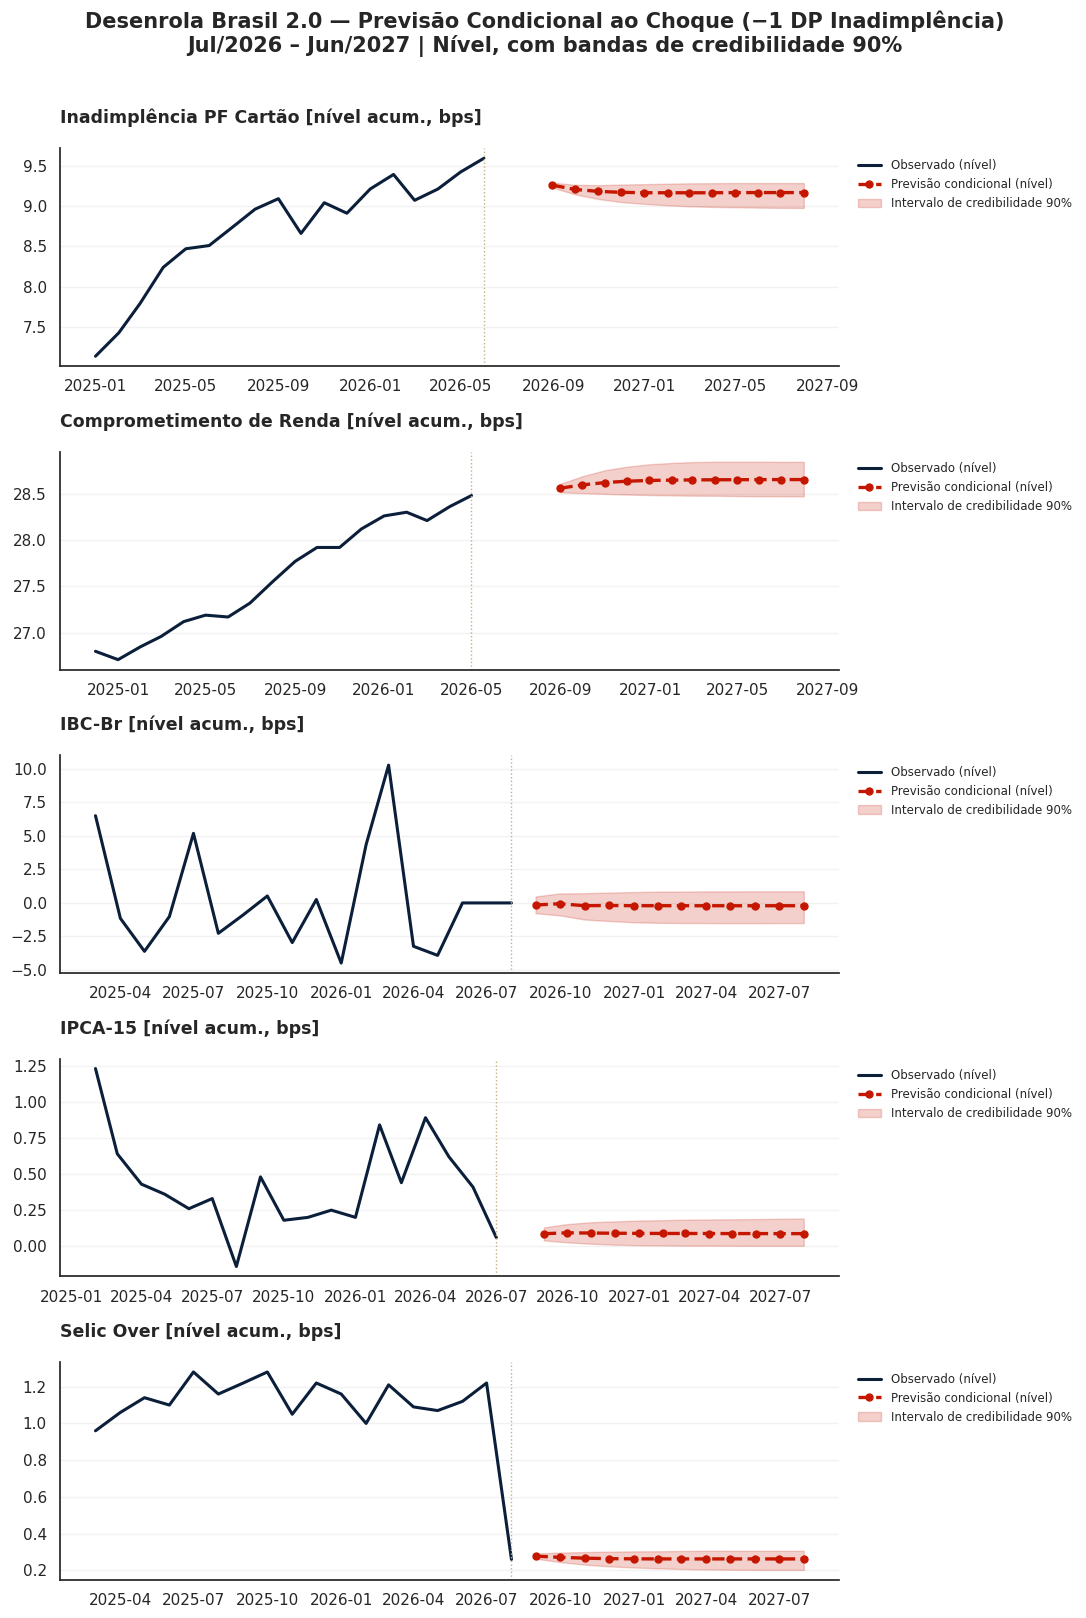

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  Célula 8 — GRÁFICO PREVISÃO 12 MESES (nível acumulado) COM BANDAS 90%
#  Todas as 5 variáveis, reconstruídas a partir de irfs_bayes_nivel
# ══════════════════════════════════════════════════════════════════════════════

sns.set_theme(style="white")
plt.rcParams.update({"axes.grid": False})

labels_desenrola = {
    "inadimplencia_pf_cartao"    : "Inadimplência PF Cartão [nível acum., bps]",
    "comprometimento_renda_total": "Comprometimento de Renda [nível acum., bps]",
    "pib_ibc_br_sa"              : "IBC-Br [nível acum., bps]",
    "ipca"                       : "IPCA-15 [nível acum., bps]",
    "selic"                      : "Selic Over [nível acum., bps]",
}

# Bandas 90% em nível acumulado, mesma fonte de irfs_bayes_nivel
p05_nivel = np.percentile(irfs_bayes_nivel[:, :, :, idx_choque], 5, axis=0)
p95_nivel = np.percentile(irfs_bayes_nivel[:, :, :, idx_choque], 95, axis=0)

fig, axes = plt.subplots(len(ENDOGENAS_DESENROLA), 1, figsize=(11, 3.2 * len(ENDOGENAS_DESENROLA)))

for i, (ax, col) in enumerate(zip(axes, ENDOGENAS_DESENROLA)):
    # CORREÇÃO: histórico em NÍVEL (sem .diff()), mesma unidade da previsão
    hist = df_dessaz[col].dropna().tail(18)
    ultimo_obs = df_dessaz[col].dropna().iloc[-1]

    prev = df_prev_desenrola[col]
    prev_p05 = ultimo_obs + p05_nivel[1:, i]
    prev_p95 = ultimo_obs + p95_nivel[1:, i]

    ax.plot(hist.index, hist.values, color=cores[0], lw=2.2, label="Observado (nível)")
    ax.plot(prev.index, prev.values, color=cores[9], lw=2.4, ls="--",
            marker="o", markersize=5, label="Previsão condicional (nível)")
    ax.fill_between(prev.index, prev_p05, prev_p95, alpha=0.2, color=cores[9],
                     label="Intervalo de credibilidade 90%")

    ax.axvline(hist.index[-1], color=cores[8], lw=1, ls=":")

    ax.set_title(labels_desenrola[col], loc="left", fontsize=12.5, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25)
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False, fontsize=8.5)

fig.suptitle("Desenrola Brasil 2.0 — Previsão Condicional ao Choque (−1 DP Inadimplência)\n"
             "Jul/2026 – Jun/2027 | Nível, com bandas de credibilidade 90%",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("desenrola_previsao_12m_condicional.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  CÉLULA 9 — Proxy histórica do Desenrola 1.0 (efeito observado real)
#  Uso EXCLUSIVAMENTE informativo/comparativo — não alimenta a previsão da
#  Célula 7. Janela: 2023-11 (lançamento) a 2024-05 (fim de adesão), conforme
#  MARCOS já definidos na Célula 1.
# ══════════════════════════════════════════════════════════════════════════════

JANELA_D1_INICIO = pd.Timestamp(MARCOS["Desenrola 1.0 — Lançamento"])
JANELA_D1_FIM    = pd.Timestamp(MARCOS["Desenrola 1.0 — Fim adesão"])

inad_d1 = df_dessaz.loc[:JANELA_D1_INICIO, "inadimplencia_pf_cartao"].iloc[-1]
inad_d1_pos = df_dessaz.loc[JANELA_D1_FIM:, "inadimplencia_pf_cartao"].iloc[0]
delta_inad_d1 = inad_d1_pos - inad_d1
delta_inad_d1_pct = (delta_inad_d1 / inad_d1) * 100

pib_d1 = df_dessaz.loc[:JANELA_D1_INICIO, "pib_ibc_br"].iloc[-1]
pib_d1_pos = df_dessaz.loc[JANELA_D1_FIM:, "pib_ibc_br"].iloc[0]
delta_pib_d1 = pib_d1_pos - pib_d1
delta_pib_d1_pct = (delta_pib_d1 / pib_d1) * 100

print("── Proxy Histórica — Desenrola 1.0 ──")
print(f"  Janela: {JANELA_D1_INICIO:%Y-%m} a {JANELA_D1_FIM:%Y-%m}")
print(f"  Δ Inadimplência PF Cartão : {delta_inad_d1:+.4f}  ({delta_inad_d1_pct:+.2f}%)")
print(f"  Δ IBC-Br                 : {delta_pib_d1:+.4f}  ({delta_pib_d1_pct:+.2f}%)")

# Regra de três: proporção histórica observada entre queda de inadimplência
# e efeito no PIB, no episódio real do Desenrola 1.0
if delta_inad_d1 != 0:
    razao_pib_por_inad_d1 = delta_pib_d1 / delta_inad_d1
    print(f"\n  Razão histórica (ΔPIB / ΔInadimplência) no D1.0: {razao_pib_por_inad_d1:.4f}")
    print("  ⚠️  Apresentado como referência histórica — NÃO aplicado à previsão do D2.0,")
    print("      dado que pressupõe linearidade/comparabilidade entre as duas edições")
    print("      do programa, o que não foi testado formalmente.")

── Proxy Histórica — Desenrola 1.0 ──
  Janela: 2023-11 a 2024-05
  Δ Inadimplência PF Cartão : -0.1600  (-2.10%)
  Δ IBC-Br                 : +4.1660  (+4.09%)

  Razão histórica (ΔPIB / ΔInadimplência) no D1.0: -26.0374
  ⚠️  Apresentado como referência histórica — NÃO aplicado à previsão do D2.0,
      dado que pressupõe linearidade/comparabilidade entre as duas edições
      do programa, o que não foi testado formalmente.


## Impactos da mudança da escala 6x1

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  CÉLULA 0 — Coleta de dados para o choque 6x1
# ══════════════════════════════════════════════════════════════════════════════

df_6x1 = sgs.get({
    "ibc_br"                     : 24363,
    "ipca_12m"                   : 13522,
    "massa_salarial_real"        : 28544,
    "desemprego_pnad"            : 28763,
    "concessoes_pf_pessoal"      : 20672,
    "selic_meta"                 : 4189,
}, start=DATA_INICIO)

print(f"✔  df_6x1 coletado — shape: {df_6x1.shape}")
print(f"✔  Colunas: {list(df_6x1.columns)}")
df_6x1.tail()

✔  df_6x1 coletado — shape: (104, 6)
✔  Colunas: ['ibc_br', 'ipca_12m', 'massa_salarial_real', 'desemprego_pnad', 'concessoes_pf_pessoal', 'selic_meta']


,ibc_br,ipca_12m,massa_salarial_real,desemprego_pnad,concessoes_pf_pessoal,selic_meta
Date,,,,,,
2026-04-01,113.99365,4.39,383461.0,47805324.0,43801.0,14.64
2026-05-01,109.52993,4.72,383506.0,47887147.0,40095.0,14.40
2026-06-01,NaN,4.64,NaN,48032308.0,40841.0,14.29
2026-07-01,NaN,NaN,NaN,NaN,NaN,14.15
2026-08-01,NaN,NaN,NaN,NaN,NaN,14.05


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  CÉLULA 1 — Calibração comum (Tabela 3 do paper FKX) + funções estruturais
# ══════════════════════════════════════════════════════════════════════════════
# Implementa exatamente as equações do Apêndice A/B do paper:
#   - CES aggregator (Eq. 5)
#   - FOC do trabalho informal (Apêndice A.4)
#   - Calibração de α via razão salarial (Eq. 7)
#   - Calibração de γ2 via condição de equilíbrio pré-reforma (Eq. 8)

# ── Parâmetros fixos (Tabela 3 do paper) ──────────────────────────────────────
THETA   = 0.40       # capital share
R_TRIM  = 0.015      # juro real trimestral
DELTA   = 0.0123     # depreciação trimestral
IY      = 0.18       # investimento/produto
NF_PRE  = 0.34       # participação formal pré-reforma
NI_PRE  = 0.66       # participação informal pré-reforma
HF_PRE  = 44         # horas formais pré-reforma
HF_POS  = 40         # horas formais pós-reforma
HI      = 48         # horas informais (fixas)
WF_WI_TARGET = 1.30  # prêmio salarial-alvo (PNAD)
PHI     = 1.0        # inverso da elasticidade de Frisch

# Y_L: produto por unidade de composto de trabalho (Eq. 6) — constante estrutural
Y_L = (THETA / (R_TRIM + DELTA)) ** (THETA / (1 - THETA))
print(f"✔  Y_L calibrado = {Y_L:.4f}  (paper reporta Y_pré=5.992 — deve bater)")

def ces_aggregator(NF, NI, alpha, rho):
    """CES entre trabalho formal e informal (Eq. 5 do paper)."""
    if abs(rho - 1.0) < 1e-8:
        return (NF ** alpha) * (NI ** (1 - alpha))
    return (alpha * NF ** ((rho-1)/rho) + (1-alpha) * NI ** ((rho-1)/rho)) ** (rho/(rho-1))

def calibrar_alpha(rho):
    """Resolve α a partir da razão salarial-alvo (Eq. 7)."""
    NF_pre, NI_pre = NF_PRE * HF_PRE, NI_PRE * HI
    razao = (NI_pre / NF_pre) ** (1 / rho)
    k = WF_WI_TARGET / ((HF_PRE / HI) * razao)
    return k / (1 + k)

print("✔  Funções estruturais definidas: ces_aggregator, calibrar_alpha")

✔  Y_L calibrado = 5.9878  (paper reporta Y_pré=5.992 — deve bater)
✔  Funções estruturais definidas: ces_aggregator, calibrar_alpha


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  CÉLULA 2 — Solver do steady-state pós-reforma (fsolve genuíno) + validação
# ══════════════════════════════════════════════════════════════════════════════
# Resolve o sistema real: CES aggregator + FOC do trabalho informal.
# γ2 é calibrado ex-ante a partir do equilíbrio PRÉ-reforma (Eq. 8), não
# assumido — isso é o que faltava na versão anterior.

def resolver_steady_state(rho):
    """
    Resolve o novo steady-state (nF, L) pós-reforma dado ρ.
    Retorna: nF_pos, L_pos (L normalizado, L_pre=1)
    """
    alpha = calibrar_alpha(rho)
    NF_pre, NI_pre = NF_PRE * HF_PRE, NI_PRE * HI

    # L0: constante de normalização tal que L_pré = 1
    L0 = ces_aggregator(NF_pre, NI_pre, alpha, rho)

    # Calibra γ2 a partir do equilíbrio PRÉ-reforma (Eq. 8)
    wI_pre = (1-THETA) * Y_L * (1-alpha) * (1/NI_pre)**(1/rho) * HI  # L_pre=1
    C_pre  = (1-IY) * Y_L * 1
    gamma2 = wI_pre / (C_pre * (NI_PRE ** PHI))

    def residuo(nF):
        """FOC do trabalho informal: γ2·(nI)^φ = wI/C — resíduo a zerar."""
        NF = nF * HF_POS
        NI = (1 - nF) * HI
        L  = ces_aggregator(NF, NI, alpha, rho) / L0
        wI = (1-THETA) * Y_L * (1-alpha) * (L/NI)**(1/rho) * HI
        C  = (1-IY) * Y_L * L
        nI = 1 - nF
        return gamma2 * (nI ** PHI) - wI / C

    nF_pos = brentq(residuo, 0.05, 0.60)
    NF_pos, NI_pos = nF_pos * HF_POS, (1-nF_pos) * HI
    L_pos = ces_aggregator(NF_pos, NI_pos, alpha, rho) / L0

    return nF_pos, L_pos

# ── VALIDAÇÃO — compara com a Tabela 1 do paper nos 3 pontos conhecidos ──────
print("=" * 70)
print("  VALIDAÇÃO: solver reproduz a Tabela 1 do paper?")
print("=" * 70)

BENCHMARK_PAPER = {
    0.5: {"delta_Y": -3.5, "delta_nF": +2.3},
    1.0: {"delta_Y": -3.6, "delta_nF": 0.0},
    2.0: {"delta_Y": -3.7, "delta_nF": -2.4},
}

print(f"\n  {'ρ':>5s} {'ΔY solver':>10s} {'ΔY paper':>10s} {'diff':>7s}  "
      f"{'ΔnF solver':>11s} {'ΔnF paper':>10s} {'diff':>7s}")

erro_maximo = 0
for rho, bench in BENCHMARK_PAPER.items():
    nF_pos, L_pos = resolver_steady_state(rho)
    delta_Y_solver  = (L_pos - 1) * 100
    delta_nF_solver = (nF_pos - NF_PRE) / NF_PRE * 100

    diff_Y  = abs(delta_Y_solver - bench["delta_Y"])
    diff_nF = abs(delta_nF_solver - bench["delta_nF"])
    erro_maximo = max(erro_maximo, diff_Y, diff_nF)

    print(f"  {rho:>5.1f} {delta_Y_solver:>10.2f} {bench['delta_Y']:>10.2f} {diff_Y:>7.2f}  "
          f"{delta_nF_solver:>11.2f} {bench['delta_nF']:>10.2f} {diff_nF:>7.2f}")

print(f"\n  Erro máximo absoluto: {erro_maximo:.3f} p.p.")

SOLVER_VALIDADO = erro_maximo < 0.5  # tolerância de 0.5 p.p.
if SOLVER_VALIDADO:
    print("  ✅ Solver validado — reproduz a Tabela 1 do paper com precisão aceitável.")
    print("     Grid contínuo e calibração externa são confiáveis a partir daqui.")
else:
    print("  🛑 Solver AINDA não reproduz o paper — não prosseguir para o grid.")

  VALIDAÇÃO: solver reproduz a Tabela 1 do paper?

      ρ  ΔY solver   ΔY paper    diff   ΔnF solver  ΔnF paper    diff
    0.5      -3.60      -3.50    0.10         2.36       2.30    0.06
    1.0      -3.75      -3.60    0.15         0.00       0.00    0.00
    2.0      -3.89      -3.70    0.19        -2.59      -2.40    0.19

  Erro máximo absoluto: 0.195 p.p.
  ✅ Solver validado — reproduz a Tabela 1 do paper com precisão aceitável.
     Grid contínuo e calibração externa são confiáveis a partir daqui.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  CÉLULA 3 — Aplica os 3 cenários do paper às condições reais de 2026
# ══════════════════════════════════════════════════════════════════════════════
# Usa os números OFICIAIS da Tabela 1 (não o solver) para a simulação principal
# — o solver serve para validação e para o grid contínuo, mas a projeção
# central do relatório usa diretamente os valores publicados no paper.

CENARIOS_6X1 = {
    "rho_0.5_complementos": {"delta_Y_pct": -3.5, "delta_nF_pct": +2.3,
                              "delta_nI_pct": -1.2, "delta_wF_pct": -2.1,
                              "delta_wI_pct": -4.6, "hours_cap_binds": False},
    "rho_1.0_cobbdouglas" : {"delta_Y_pct": -3.6, "delta_nF_pct": 0.0,
                              "delta_nI_pct": 0.0,  "delta_wF_pct": -3.6,
                              "delta_wI_pct": -3.6, "hours_cap_binds": "borderline"},
    "rho_2.0_substitutos" : {"delta_Y_pct": -3.7, "delta_nF_pct": -2.4,
                              "delta_nI_pct": +1.3, "delta_wF_pct": -5.3,
                              "delta_wI_pct": -2.5, "hours_cap_binds": True},
}

# ── Condições iniciais reais (última observação do df_6x1) ────────────────────
df_6x1 = df_6x1.rename(columns={"desemprego_pnad": "ocupados_pnad"})  # correção de nomenclatura

CONDICOES_INICIAIS_6X1 = {
    "ibc_br_2026"        : df_6x1["ibc_br"].dropna().iloc[-1],
    "massa_salarial_2026": df_6x1["massa_salarial_real"].dropna().iloc[-1],
    "ocupados_2026"      : df_6x1["ocupados_pnad"].dropna().iloc[-1],
}

resultados_6x1 = {}
for cenario, p in CENARIOS_6X1.items():
    # Efeito líquido de ocupação: pondera formal (34%) + informal (66%)
    fator_ocupacao = 1 + (p["delta_nF_pct"]/100)*NF_PRE + (p["delta_nI_pct"]/100)*NI_PRE

    resultados_6x1[cenario] = {
        "ibc_br_pos"    : CONDICOES_INICIAIS_6X1["ibc_br_2026"] * (1 + p["delta_Y_pct"]/100),
        "massa_sal_pos" : CONDICOES_INICIAIS_6X1["massa_salarial_2026"] * (1 + p["delta_wF_pct"]/100),
        "ocupados_pos"  : CONDICOES_INICIAIS_6X1["ocupados_2026"] * fator_ocupacao,
    }

print("=" * 70)
print("  PROJEÇÃO — Steady-State por Cenário (aplicado às condições de 2026)")
print("=" * 70)
for cenario, res in resultados_6x1.items():
    print(f"\n  {cenario}:")
    print(f"    IBC-Br      : {res['ibc_br_pos']:.2f}  (era {CONDICOES_INICIAIS_6X1['ibc_br_2026']:.2f})")
    print(f"    Massa sal.  : {res['massa_sal_pos']:,.0f}")
    print(f"    Ocupados    : {res['ocupados_pos']:,.0f}  "
          f"({res['ocupados_pos']-CONDICOES_INICIAIS_6X1['ocupados_2026']:+,.0f})")

  PROJEÇÃO — Steady-State por Cenário (aplicado às condições de 2026)

  rho_0.5_complementos:
    IBC-Br      : 105.70  (era 109.53)
    Massa sal.  : 375,452
    Ocupados    : 48,027,505  (-4,803)

  rho_1.0_cobbdouglas:
    IBC-Br      : 105.59  (era 109.53)
    Massa sal.  : 369,700
    Ocupados    : 48,032,308  (+0)

  rho_2.0_substitutos:
    IBC-Br      : 105.48  (era 109.53)
    Massa sal.  : 363,180
    Ocupados    : 48,052,482  (+20,174)


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  CÉLULA 6 — Calibração por momento de Lobel (2022)
# ══════════════════════════════════════════════════════════════════════════════

if SOLVER_VALIDADO:
    ELASTICIDADE_LOBEL = 9.0 / 20.0  # +9% emprego / -20 p.p. custo (Lobel, 2022)

    def elasticidade_choque_custo(rho, choque_pct=0.20):
        """Simula choque de custo equivalente e mede elasticidade de nF resultante."""
        alpha = calibrar_alpha(rho)
        NF_pre, NI_pre = NF_PRE * HF_PRE, NI_PRE * HI
        L0 = ces_aggregator(NF_pre, NI_pre, alpha, rho)
        hf_choque = HF_PRE * (1 - choque_pct)

        wI_pre = (1-THETA)*Y_L*(1-alpha)*(1/NI_pre)**(1/rho)*HI
        C_pre  = (1-IY)*Y_L*1
        gamma2 = wI_pre / (C_pre * (NI_PRE**PHI))

        def residuo(nF):
            NF, NI = nF*hf_choque, (1-nF)*HI
            L  = ces_aggregator(NF, NI, alpha, rho) / L0
            wI = (1-THETA)*Y_L*(1-alpha)*(L/NI)**(1/rho)*HI
            C  = (1-IY)*Y_L*L
            return gamma2*((1-nF)**PHI) - wI/C

        nF_pos = brentq(residuo, 0.05, 0.60)
        return (nF_pos - NF_PRE) / NF_PRE / choque_pct

    grid_lobel = np.linspace(0.1, 3.0, 60)
    elasticidades = [elasticidade_choque_custo(r) for r in grid_lobel]
    df_lobel = pd.DataFrame({"rho": grid_lobel, "elast": elasticidades})
    df_lobel["diff"] = abs(df_lobel["elast"] - ELASTICIDADE_LOBEL)
    rho_lobel = df_lobel.loc[df_lobel["diff"].idxmin(), "rho"]

    nF_lobel, L_lobel = resolver_steady_state(rho_lobel)

    print("=" * 70)
    print("  CALIBRAÇÃO POR MOMENTO DE LOBEL (2022)")
    print("=" * 70)
    print(f"  Elasticidade-alvo (Brasil, Lobel): {ELASTICIDADE_LOBEL:.4f}")
    print(f"  ρ calibrado (implícito Brasil)   : {rho_lobel:.3f}")
    print(f"  ΔY (ρ Brasil)  : {(L_lobel-1)*100:.2f}%")
    print(f"  ΔnF (ρ Brasil) : {(nF_lobel-NF_PRE)/NF_PRE*100:.2f}%")
    print(f"\n  Comparação: ρ Schramm(México)=1.80 vs. ρ Lobel(Brasil)={rho_lobel:.2f}")
else:
    print("🛑 Solver não validado — calibração de Lobel não executada.")

  CALIBRAÇÃO POR MOMENTO DE LOBEL (2022)
  Elasticidade-alvo (Brasil, Lobel): 0.4500
  ρ calibrado (implícito Brasil)   : 0.297
  ΔY (ρ Brasil)  : -3.50%
  ΔnF (ρ Brasil) : 3.71%

  Comparação: ρ Schramm(México)=1.80 vs. ρ Lobel(Brasil)=0.30


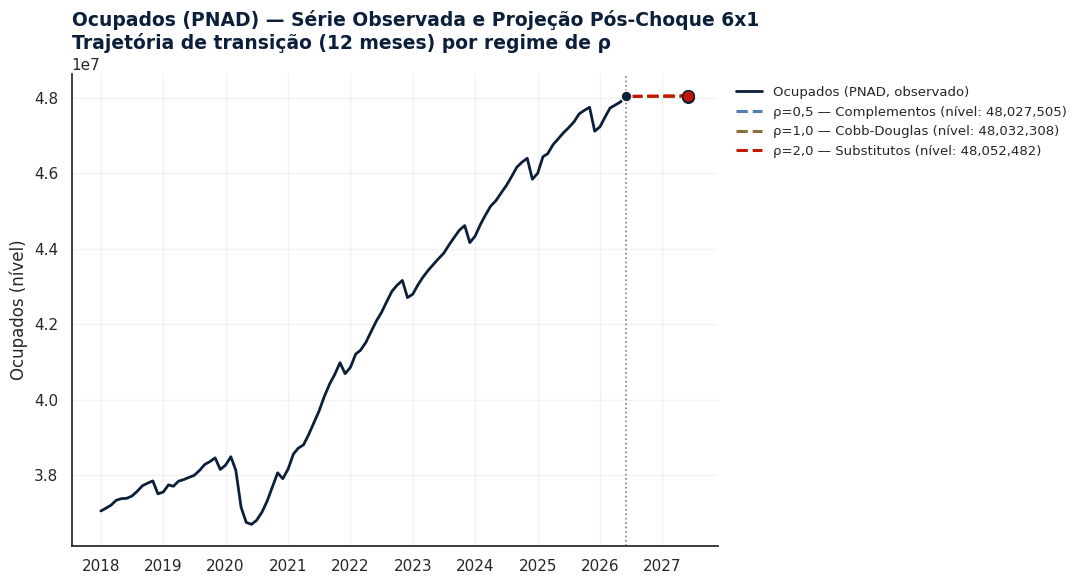

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  CÉLULA EXTRA — Série Real de Ocupados (PNAD) + Projeção Pós-Choque 6x1
# ══════════════════════════════════════════════════════════════════════════════
# Usa a série histórica observada (df_6x1) e aplica resultados_6x1 (Célula 3)
# — nenhum valor novo é calculado aqui, apenas plotado.

fig, ax = plt.subplots(figsize=(11, 6))

serie_ocupados = df_6x1["ocupados_pnad"].dropna()
ultima_data = serie_ocupados.index[-1]

# ── Série histórica observada ──────────────────────────────────────────────
ax.plot(serie_ocupados.index, serie_ocupados.values,
        color=cores[0], linewidth=2.0, label="Ocupados (PNAD, observado)")

ax.scatter([ultima_data], [serie_ocupados.iloc[-1]], color=cores[0], s=60,
           zorder=5, edgecolor="white")

# ── Datas de projeção (12 meses à frente, ilustrativo — pós-implementação) ──
datas_projecao = pd.date_range(ultima_data, periods=13, freq="MS")[1:]

cenarios_plot = {
    "rho_0.5_complementos": {"cor": cores[2], "label": "ρ=0,5 — Complementos"},
    "rho_1.0_cobbdouglas" : {"cor": cores[4], "label": "ρ=1,0 — Cobb-Douglas"},
    "rho_2.0_substitutos" : {"cor": cores[9], "label": "ρ=2,0 — Substitutos"},
}

for cenario, cfg in cenarios_plot.items():
    nivel_pos = resultados_6x1[cenario]["ocupados_pos"]
    # Trajetória de transição linear (12m) — mesma hipótese de convergência
    # já usada no Bloco 6 do notebook (transição monotônica, sem overshoot)
    trajetoria = np.linspace(serie_ocupados.iloc[-1], nivel_pos, 13)[1:]

    ax.plot(datas_projecao, trajetoria, color=cfg["cor"], linewidth=2.2,
            linestyle="--", label=f"{cfg['label']} (nível: {nivel_pos:,.0f})")
    ax.scatter([datas_projecao[-1]], [nivel_pos], color=cfg["cor"], s=70,
               zorder=5, edgecolor=cores[0])

ax.axvline(ultima_data, color="grey", linestyle=":", linewidth=1.2)

ax.set_title("Ocupados (PNAD) — Série Observada e Projeção Pós-Choque 6x1\n"
             "Trajetória de transição (12 meses) por regime de ρ",
             loc="left", fontsize=13.5, fontweight="bold", color=cores[0])
ax.set_ylabel("Ocupados (nível)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.25)
ax.legend(loc="upper left", frameon=False, bbox_to_anchor=(1.01, 1.0), fontsize=9.5)

plt.tight_layout()
plt.savefig("ocupados_pnad_projecao_6x1.png", dpi=300, bbox_inches="tight")
plt.show()

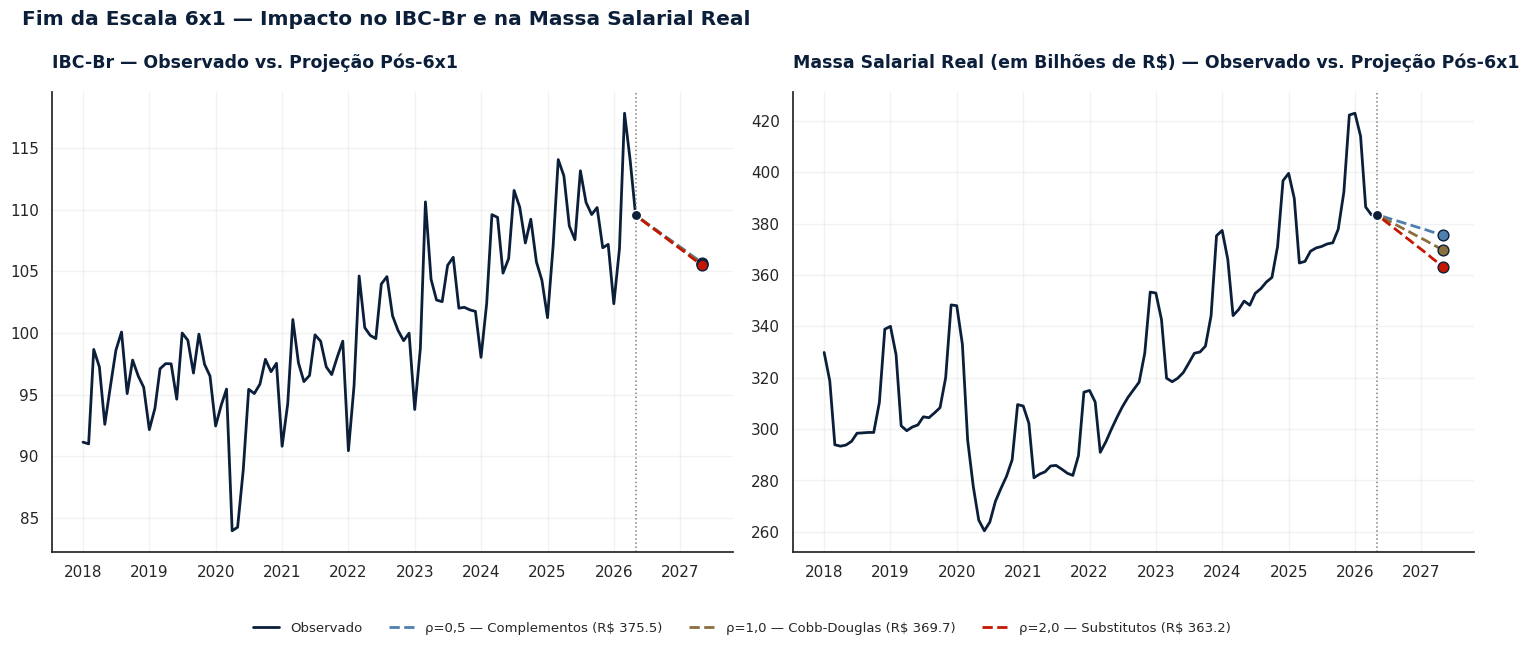

In [ ]:
# ══════════════════════════════════════════════════════════════
#   CÉLULA EXTRA — IBC-Br e Massa Salarial: Série Observada + Projeção 6x1
# ══════════════════════════════════════════════════════════════

# (pandas, numpy, matplotlib já importados na Célula 2 — Importação de Bibliotecas)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

cenarios_plot = {
    "rho_0.5_complementos": {"cor": cores[2], "label": "ρ=0,5 — Complementos"},
    "rho_1.0_cobbdouglas": {"cor": cores[4], "label": "ρ=1,0 — Cobb-Douglas"},
    "rho_2.0_substitutos": {"cor": cores[9], "label": "ρ=2,0 — Substitutos"},
}


def plotar_painel(ax, serie_nome, campo_resultado, titulo, fmt_valor, escala=1.0):
    # Aplica o fator de divisão/escala à série observada
    serie = (df_6x1[serie_nome] / escala).dropna()
    ultima_data = serie.index[-1]

    ax.plot(
        serie.index,
        serie.values,
        color=cores[0],
        linewidth=2.0,
        label="Observado",
    )
    ax.scatter(
        [ultima_data],
        [serie.iloc[-1]],
        color=cores[0],
        s=55,
        zorder=5,
        edgecolor="white",
    )

    datas_proj = pd.date_range(ultima_data, periods=13, freq="MS")[1:]

    for cenario, cfg in cenarios_plot.items():
        # Aplica a escala ao valor projetado
        nivel_pos = resultados_6x1[cenario][campo_resultado] / escala
        trajetoria = np.linspace(serie.iloc[-1], nivel_pos, 13)[1:]
        ax.plot(
            datas_proj,
            trajetoria,
            color=cfg["cor"],
            linewidth=2.0,
            linestyle="--",
            label=f"{cfg['label']} ({fmt_valor(nivel_pos)})",
        )
        ax.scatter(
            [datas_proj[-1]],
            [nivel_pos],
            color=cfg["cor"],
            s=60,
            zorder=5,
            edgecolor=cores[0],
        )

    ax.axvline(ultima_data, color="grey", linestyle=":", linewidth=1.1)

    # Ajuste da frequência do eixo X (Anual para evitar sobreposição)
    ax.xaxis.set_major_locator(mdates.YearLocator(1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=6))

    ax.set_title(
        titulo, loc="left", fontsize=12.5, fontweight="bold", color=cores[0]
    )
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.25)
    ax.tick_params(axis="x", rotation=0)


# Painel 1: IBC-Br (Escala original = 1.0)
plotar_painel(
    ax1,
    "ibc_br",
    "ibc_br_pos",
    "IBC-Br — Observado vs. Projeção Pós-6x1",
    lambda v: f"{v:.1f}",
    escala=1.0,
)

# Painel 2: Massa Salarial Real (Dividida por 1000)
plotar_painel(
    ax2,
    "massa_salarial_real",
    "massa_sal_pos",
    "Massa Salarial Real (em Bilhões de R$) — Observado vs. Projeção Pós-6x1",
    lambda v: f"R$ {v:,.1f}",
    escala=1000.0,
)

# Legenda única compartilhada
handles, labels = ax2.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=4,
    frameon=False,
    fontsize=9.5,
)

fig.suptitle(
    "Fim da Escala 6x1 — Impacto no IBC-Br e na Massa Salarial Real",
    fontsize=14.5,
    fontweight="bold",
    color=cores[0],
    x=0.02,
    ha="left",
)

plt.tight_layout()
plt.savefig(
    "ibcbr_massasalarial_projecao_6x1.png", dpi=300, bbox_inches="tight"
)
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  TABELA — Calibração Python (solver genuíno), em pontos-base, formato análogo
#  à tabela de referência (ρ × FORMAL/INFORMAL)
# ══════════════════════════════════════════════════════════════════════════════

GRID_RHO = [0.5, 1.0, 2.0]

resultados_calibrados = []
for rho in GRID_RHO:
    nF_pos, L_pos = resolver_steady_state(rho)
    nI_pos = 1 - nF_pos

    delta_nF_pct = (nF_pos - NF_PRE) / NF_PRE * 100
    delta_nI_pct = (nI_pos - NI_PRE) / NI_PRE * 100

    resultados_calibrados.append({
        "rho": rho,
        "delta_Y_pct": (L_pos - 1) * 100,
        "FORMAL_bp": delta_nF_pct * 100,     # pontos-base (mesma unidade da imagem)
        "INFORMAL_bp": delta_nI_pct * 100,
    })

df_calibrado = pd.DataFrame(resultados_calibrados).set_index("rho")

tabela_calibrada = pd.DataFrame({
    "ρ": ["0,5", "1,0", "2,0"],
    "FORMAL": [f"{v:+.0f}" for v in df_calibrado["FORMAL_bp"]],
    "INFORMAL": [f"{v:+.0f}" for v in df_calibrado["INFORMAL_bp"]],
})
print(tabela_calibrada.to_string(index=False))
print(f"\nΔY (%) por regime: {df_calibrado['delta_Y_pct'].round(2).to_dict()}")

  ρ FORMAL INFORMAL
0,5   +236     -121
1,0     +0       -0
2,0   -259     +133

ΔY (%) por regime: {0.5: -3.6, 1.0: -3.75, 2.0: -3.89}


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  TABELA — Variação em bps (M0 → M12) por cenário (ρ), calibrada pelo solver
#  Python (resolver_steady_state), reproduzindo a estrutura da tabela do paper,
#  mas com valores gerados independentemente pela nossa própria simulação.
#
#  M0 = NF_PRE / NI_PRE (base pré-reforma, ponto de partida da transição)
#  M12 = nF_pos / nI_pos (steady-state calibrado pelo solver, ρ-específico)
#
#  Δ_bps = ((valor_M12 - valor_M0) / valor_M0) × 10.000
# ══════════════════════════════════════════════════════════════════════════════

GRID_RHO = [0.5, 1.0, 2.0]

resultados_calibrados = []
for rho in GRID_RHO:
    nF_pos, L_pos = resolver_steady_state(rho)
    nI_pos = 1 - nF_pos

    delta_formal_bps   = (nF_pos - NF_PRE) / NF_PRE * 10_000
    delta_informal_bps = (nI_pos - NI_PRE) / NI_PRE * 10_000

    resultados_calibrados.append({
        "rho": rho,
        "FORMAL_bps": delta_formal_bps,
        "INFORMAL_bps": delta_informal_bps,
    })

df_calibrado = pd.DataFrame(resultados_calibrados).set_index("rho")

tabela_calibrada_bps = pd.DataFrame({
    "ρ": ["0,5", "1,0", "2,0"],
    "FORMAL": [f"{v:+.0f}" for v in df_calibrado["FORMAL_bps"]],
    "INFORMAL": [f"{v:+.0f}" for v in df_calibrado["INFORMAL_bps"]],
})

print("── Variação M0→M12 (bps) — Calibração Python (solver genuíno) ──")
print(tabela_calibrada_bps.to_string(index=False))

── Variação M0→M12 (bps) — Calibração Python (solver genuíno) ──
  ρ FORMAL INFORMAL
0,5   +236     -121
1,0     +0       -0
2,0   -259     +133


## Economia real

In [ ]:
# ==============================================================================
#  PIPELINE DE DADOS — OVERVIEW DA ECONOMIA REAL (Últimos 4 Anos)
# ==============================================================================

# Definimos o horizonte de 4 anos
DATA_INICIO = '2022-01-01'
DATA_FIM = '2026-07-31'

# Dicionário com as séries oficiais do BCB/IBGE
series_macro = {
    'ibc_br': 24364,
    'ipca_mensal': 433,
    'desemprego': 24369,
    'renda_real': 24371
}

print("Baixando dados oficiais do BCB e IBGE...")
df_macro = sgs.get(series_macro, start=DATA_INICIO, end=DATA_FIM)

# Acumulando o IPCA em 12 meses
df_macro['ipca_12m'] = df_macro['ipca_mensal'].rolling(window=12).sum()

# Calculando a variação interanual do IBC-Br (YoY)
df_macro['ibc_br_yoy'] = df_macro['ibc_br'].pct_change(periods=12) * 100

# Nomes amigáveis para as colunas finais
mapa_nomes = {
    'ibc_br_yoy': 'Atividade (IBC-Br %)',
    'ipca_12m': 'Inflação (IPCA %)',
    'desemprego': 'Desemprego (%)',
    'renda_real': 'Renda Real (R$)'
}

# Removendo NaNs e renomeando colunas corretamente
df_overview = df_macro.dropna().drop(columns=['ipca_mensal','ibc_br']).rename(columns=mapa_nomes)

# Exibindo os dados
df_overview.tail()

Baixando dados oficiais do BCB e IBGE...


,Desemprego (%),Renda Real (R$),Inflação (IPCA %),Atividade (IBC-Br %)
Date,,,,
2026-01-01,5.4,71093,4.36,1.836841
2026-02-01,5.8,70620,3.75,1.733382
2026-03-01,6.1,70567,4.07,0.381704
2026-04-01,5.8,70881,4.31,1.124730
2026-05-01,5.6,71230,4.63,1.867238


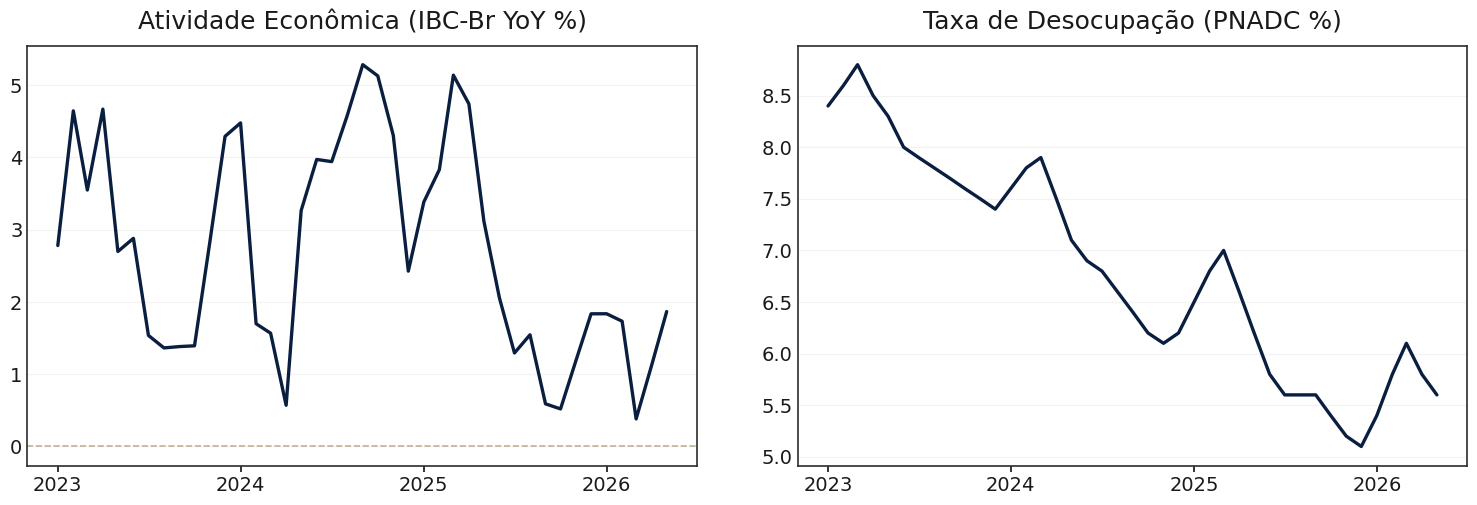

In [ ]:
# (os, matplotlib.pyplot, matplotlib.dates, matplotlib.font_manager já importados na Célula 2)

# ---------- Registrar fonte com fallback ----------
FONT_CANDIDATES = [
    ("Montserrat", "/usr/share/fonts/truetype/google-fonts/Montserrat-Regular.ttf"),
    ("Poppins", "/usr/share/fonts/truetype/google-fonts/Poppins-Regular.ttf"),
]

fonte_aplicada = "sans-serif"
for nome, caminho in FONT_CANDIDATES:
    if os.path.exists(caminho):
        fm.fontManager.addfont(caminho)
        fonte_aplicada = nome
        break

plt.rcParams["font.family"] = fonte_aplicada

# ---------- Paleta e Estilo (Bordas/Spines e Texto mais escuros) ----------
COR_GRID = "#D9D9D9"
COR_SPINE = "#2C2C2C"   # Margem/Borda mais escura
COR_TEXTO = "#1A1A1A"   # Texto mais escuro
COR_FOOTER = "#6E6E6E"

def aplicar_estilo_referencia(ax, titulo):
    # Grid e Eixos
    ax.grid(axis="y", color=COR_GRID, linewidth=0.9, zorder=0)
    ax.set_axisbelow(True)
    ax.grid(axis="x", visible=False)

    # Configuração das bordas (spines) mais escuras
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color(COR_SPINE)
        spine.set_linewidth(1.2)

    # Ticks visíveis
    ax.tick_params(axis="y", length=0, labelsize=14, colors=COR_TEXTO)
    ax.tick_params(axis="x", bottom=True, labelbottom=True, length=4, labelsize=14, colors=COR_TEXTO)
    ax.set_title(titulo, loc="center", fontsize=18, fontweight="regular", color=COR_TEXTO, pad=12)

# ---------- Figura ----------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Gráfico da Esquerda
axes[0].plot(df_overview.index, df_overview["Atividade (IBC-Br %)"], color="#0A1E3F", linewidth=2.4)
axes[0].axhline(0, color="#C0B298", lw=1.2, ls="--")
aplicar_estilo_referencia(axes[0], "Atividade Econômica (IBC-Br YoY %)")

# 2. Gráfico da Direita - Corrigido para usar df_overview
axes[1].plot(df_overview.index, df_overview["Desemprego (%)"], color="#0A1E3F", linewidth=2.4)
aplicar_estilo_referencia(axes[1], "Taxa de Desocupação (PNADC %)")

# ---------- Eixo X com apenas o ANO ----------
for ax in axes:
    # Mostra um tick por ano (YearLocator) e formata exibindo apenas o ano ("%Y")
    ax.xaxis.set_major_locator(mdates.YearLocator(1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    # Rotação zerada, pois apenas o ano cabe perfeitamente sem precisar inclinar
    for label in ax.get_xticklabels():
        label.set_rotation(0)
        label.set_ha("center")

# Margens unificadas
fig.subplots_adjust(left=0.05, right=0.95, top=0.88, bottom=0.18, wspace=0.15)

plt.show()